https://portal.azure.com

Recurso 'Computer Vision''

VisualFeatures.CAPTION
VisualFeatures.DENSE_CAPTIONS
VisualFeatures.TAGS
VisualFeatures.OBJECTS
VisualFeatures.PEOPLE

In [6]:
# requirements

# pip install dotenv
# pip install matplotlib
# pip install pillow
# pip install azure-ai-vision-imageanalysis==1.0.0

### image-analysis.py

Usando arquivo de imagem: images/street.jpg

Analyzing images/street.jpg


Caption:
 Caption: 'a man walking a dog on a leash on a street' (confidence: 82.05%)

Dense Captions:
 Caption: 'a man walking a dog on a leash on a street' (confidence: 82.06%)
 Caption: 'a man walking on a street' (confidence: 69.03%)
 Caption: 'a yellow car on the street' (confidence: 78.17%)
 Caption: 'a black dog walking on the street' (confidence: 75.31%)
 Caption: 'a blurry image of a blue car' (confidence: 82.01%)
 Caption: 'a yellow taxi cab on the street' (confidence: 72.44%)

Tags:
 Tag: 'outdoor' (confidence: 99.87%)
 Tag: 'land vehicle' (confidence: 99.02%)
 Tag: 'vehicle' (confidence: 98.89%)
 Tag: 'building' (confidence: 98.55%)
 Tag: 'road' (confidence: 95.98%)
 Tag: 'wheel' (confidence: 95.14%)
 Tag: 'street' (confidence: 94.71%)
 Tag: 'person' (confidence: 93.01%)
 Tag: 'clothing' (confidence: 91.19%)
 Tag: 'taxi' (confidence: 90.95%)
 Tag: 'car' (confidence: 84.01%)
 Tag: 'dog' (confidence: 82

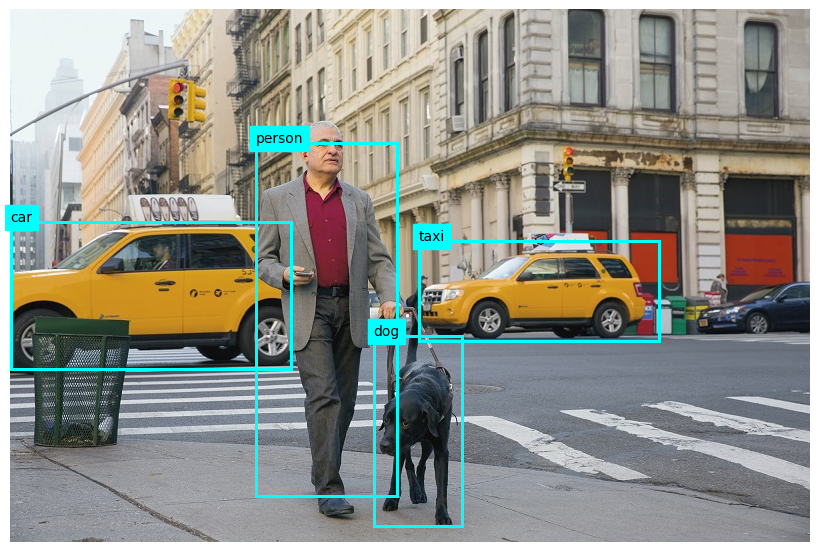

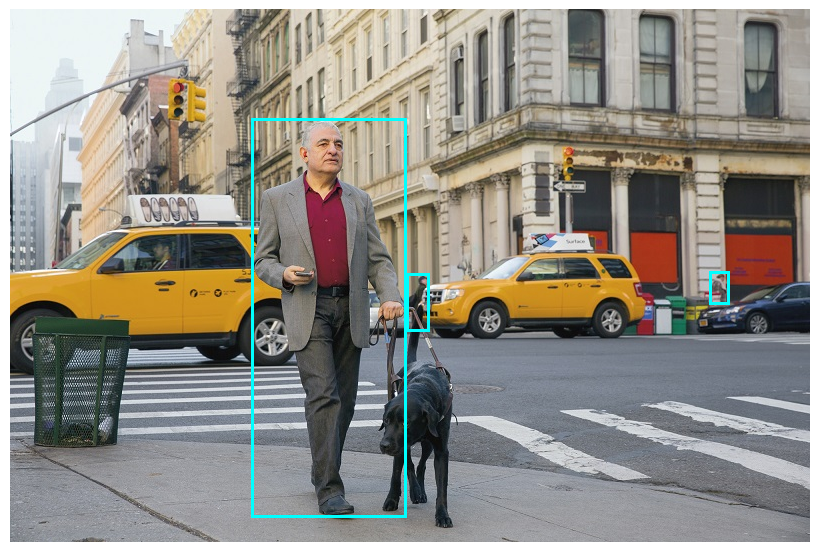

In [11]:
from dotenv import load_dotenv
import os
from PIL import Image, ImageDraw
import sys
from matplotlib import pyplot as plt
from azure.core.exceptions import HttpResponseError
import requests

# import namespaces
from azure.ai.vision.imageanalysis import ImageAnalysisClient
from azure.ai.vision.imageanalysis.models import VisualFeatures
from azure.core.credentials import AzureKeyCredential


def get_user_args():
    """
    Retorna apenas os argumentos 'do usuário',
    ignorando os internos do Jupyter (ex: --f=/...kernel.json)
    """
    return [
        a for a in sys.argv[1:]
        if not a.startswith("-f=") and not a.startswith("--f=") and a != "-f"
    ]


def main():

    # Em notebook, limpar console não faz muito sentido, mas não quebra nada
    os.system('cls' if os.name == 'nt' else 'clear')

    try:
        # Get Configuration Settings
        load_dotenv()
        ai_endpoint = os.getenv('AI_SERVICE_ENDPOINT', "") 
        ai_key = os.getenv('AI_SERVICE_KEY', "")

        # Default image
        image_file = 'images/street.jpg'

        # Pega apenas argumentos "reais" (ignora o -f do Jupyter)
        user_args = get_user_args()
        if user_args:
            image_file = user_args[0]

        print(f"Usando arquivo de imagem: {image_file}")

        # Authenticate Azure AI Vision client
        cv_client = ImageAnalysisClient(
            endpoint=ai_endpoint,
            credential=AzureKeyCredential(ai_key)
        )

        # Analyze image
        with open(image_file, "rb") as f:
            image_data = f.read()
        print(f'\nAnalyzing {image_file}\n')

        result = cv_client.analyze(
            image_data=image_data,
            visual_features=[
                VisualFeatures.CAPTION,
                VisualFeatures.DENSE_CAPTIONS,
                VisualFeatures.TAGS,
                VisualFeatures.OBJECTS,
                VisualFeatures.PEOPLE,
            ]
        )

        # Get image captions
        if result.caption is not None:
            print("\nCaption:")
            print(" Caption: '{}' (confidence: {:.2f}%)".format(
                result.caption.text, result.caption.confidence * 100
            ))
            
        if result.dense_captions is not None:
            print("\nDense Captions:")
            for caption in result.dense_captions.list:
                print(" Caption: '{}' (confidence: {:.2f}%)".format(
                    caption.text, caption.confidence * 100
                ))        

        # Get image tags
        if result.tags is not None:
            print("\nTags:")
            for tag in result.tags.list:
                print(" Tag: '{}' (confidence: {:.2f}%)".format(tag.name, tag.confidence * 100))

        # Get objects in the image
        if result.objects is not None:
            print("\nObjects in image:")
            for detected_object in result.objects.list:
                # Print object tag and confidence
                print(" {} (confidence: {:.2f}%)".format(detected_object.tags[0].name, detected_object.tags[0].confidence * 100))
            # Annotate objects in the image
            show_objects(image_file, result.objects.list)

        # Get people in the image
        if result.people is not None:
            print("\nPeople in image:")

            for detected_person in result.people.list:
                if detected_person.confidence > 0.2:
                    # Print location and confidence of each person detected
                    print(" {} (confidence: {:.2f}%)".format(detected_person.bounding_box, detected_person.confidence * 100))
            # Annotate people in the image
            show_people(image_file, result.people.list)

    except Exception as ex:
        print("Erro na análise:")
        print(ex)


def show_objects(image_filename, detected_objects):
    print("\nAnnotating objects...")

    # Prepare image for drawing
    image = Image.open(image_filename)
    fig = plt.figure(figsize=(image.width/100, image.height/100))
    plt.axis('off')
    draw = ImageDraw.Draw(image)
    color = 'cyan'

    for detected_object in detected_objects:
        # Draw object bounding box
        r = detected_object.bounding_box
        bounding_box = ((r.x, r.y), (r.x + r.width, r.y + r.height)) 
        draw.rectangle(bounding_box, outline=color, width=3)
        plt.annotate(detected_object.tags[0].name, (r.x, r.y), backgroundcolor=color)

    # Save annotated image
    plt.imshow(image)
    plt.tight_layout(pad=0)
    objectfile = 'objects.jpg'
    fig.savefig(objectfile)
    print('  Results saved in', objectfile)


def show_people(image_filename, detected_people):
    print("\nAnnotating people...")

    # Prepare image for drawing
    image = Image.open(image_filename)
    fig = plt.figure(figsize=(image.width/100, image.height/100))
    plt.axis('off')
    draw = ImageDraw.Draw(image)
    color = 'cyan'

    for detected_person in detected_people:
        if detected_person.confidence > 0.2:
            # Draw object bounding box
            r = detected_person.bounding_box
            bounding_box = ((r.x, r.y), (r.x + r.width, r.y + r.height))
            draw.rectangle(bounding_box, outline=color, width=3)

    # Save annotated image
    plt.imshow(image)
    plt.tight_layout(pad=0)
    peoplefile = 'people.jpg'
    fig.savefig(peoplefile)
    print('  Results saved in', peoplefile)


if __name__ == "__main__":
    main()
